In [3]:
import sys
from pathlib import Path

_root = Path.cwd()  # assumes notebook is run from the project root
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

import matplotlib.pyplot as plt
import numpy as np
import h5py
import copy
import pandas as pd
from scipy import optimize
from matplotlib import pyplot as plt
import pickle
from itertools import cycle
import matplotlib.colors as mcolors
import astropy.units as u
import astropy.constants as const
import heapq

from photochem.utils import stars
import PICASO_Climate_grid_121625 as picaso_grid
import Photochem_grid_121625 as Photochem_grid
import Reflected_Spectra_grid_13026 as Reflected_Spectra
from picaso.photochem import EquilibriumChemistry
import GraphsKey

import os
from pathlib import Path
from cycler import cycler

current_directory = Path.cwd()
references_directory_path = "Installation_Setup_Instructions/picasofiles/reference"
PYSYN_directory_path = "Installation_Setup_Instructions/picasofiles/grp/redcat/trds"
print(os.path.join(current_directory, references_directory_path))
print(os.path.join(current_directory, PYSYN_directory_path))

os.environ['picaso_refdata']= os.path.join(current_directory, references_directory_path)
os.environ['PYSYN_CDBS']= os.path.join(current_directory, PYSYN_directory_path)


import picaso.justdoit as jdi
import picaso.justplotit as jpi

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference/opacities/opacities_photochem_0.1_250.0_R15000_v2.db
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/reference
/mnt/c/Users/lily/Documents/NASAUWPostbac/MiniNeptuneGrid26_PostBac/Installation_Setup_Instructions/picasofiles/grp/redcat/trds


# Case 1 - The Mini Neptune our Paper Focuses On

Parameters:
- planet radius: 2x Earth Radius
- metallicity: 2x (logspace) x solar (~100x solar metallicity)
- tint: 50K
- semi major: 1 AU
- ctoO_solar: 0.7525 x solar c/o ratio
- kzz: 5 cm^2/s

In [4]:
rad_plan = 2
log10_metal = 2
tint = 50
semi_major = 1
ctoO = 0.7525
Kzz = 5

In [21]:
# Look at PT Profile & Plot
PT_list_picaso_old, convergence_values, picaso_converged, error_status = Photochem_grid.find_PT_grid(
    filename='data/grid_results/PICASO_climate_updatop_full_exploration_reducedrad_solveSegFault.h5',
    rad_plan=rad_plan, log10_planet_metallicity=log10_metal,
    tint=tint, semi_major=semi_major, ctoO=ctoO
)


Was able to successfully find your input parameters in the PICASO TP profile grid!


In [6]:
# Look at Photochem Profile & Plot
sol_dict, soleq_dict, PT_list, convergence_PC, convergence_TP = Reflected_Spectra.find_Photochem_match(filename='data/grid_results/Photochem_1D_updatop_paramext_reducedrad_full_try3.h5', rad_plan=rad_plan, log10_planet_metallicity=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO,Kzz=Kzz)

Was able to successfully find your input parameters in the PICASO TP profile grid!


In [8]:
# Re-run PT profile calculation on new environment (subneptune_nb_picaso)
import sys
from pathlib import Path
import os

_root = Path.cwd()
sys.path.insert(0, str(_root / 'MiniNepGrid_Scripts'))
sys.path.insert(0, str(_root / 'ReflectedSpectra_Scripts'))

os.environ['picaso_refdata'] = str(_root / 'Installation_Setup_Instructions/picasofiles/reference')
os.environ['PYSYN_CDBS']     = str(_root / 'Installation_Setup_Instructions/picasofiles/grp/redcat/trds')

# ─── Replace these values with the case you want to re-run ───────────────────
CASE = [rad_plan, log10_metal, tint, semi_major, ctoO]
# ─────────────────────────────────────────────────────────────────────────────

import PICASO_Climate_grid_121625 as picaso_grid

result = picaso_grid.PICASO_climate_model(x=CASE)
print("Status :", result.get('status'))
print("Converged:", result.get('converged'))
if b'error' in result.get('status', b''):
    print("Error  :", result.get('error'))

2026-07-23 16:24:47,022 INFO: starting climate model for inputs: [2, 2, 50, 1, 0.7525]


This is the value of [2, 2, 50, 1, 0.7525] used in the climate model
Input Values: rad_plan=2.0, mh=2.0, tint=50.0, semi_major_AU=1.0, ctoO=0.7525


2026-07-23 16:24:47,210 INFO: Loading opacity table (first call in this process)...


SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  240.04687211335087 743.5758477792399 , flux balance  180.42462419341246
Iteration number  1 , min , max temp  240.06129863067912 751.7777404661894 , flux balance  180.39272305383517
Iteration number  2 , min , max temp  240.07490712759815 759.9322046335412 , flux balance  180.35939034061735
Iteration number  3 , min , max temp  240.08836859227253 768.0389594923422 , flux balance  180.3245846184637
Iteration number  4 , min , max temp  240.10189758057876 776.1074436871091 , flux balance  180.28826359836643
Iteration number  5 , min , max temp  240.11559527412194 784.1376395396348 , flux balance  180.25038412090836
Iteration number  6 , min , max temp  240.12954859764906 792.1370144312025 , flux balance  180.2109021370393
Iteration number  7 , min , max temp  240.1440806832318 800.1058547039518 , flux balance  180.16977268624626
Iteration nu

2026-07-23 18:11:01,141 INFO: Loading opacity table (first call in this process)...


SUMMARY
-------
Clouds: False
quench False
cold_trap False
vol_rainout False
no_ph3 False
Moist Adiabat: False
Iteration number  0 , min , max temp  234.95200517559158 1825.2453695122008 , flux balance  15.716906929028745
Iteration number  1 , min , max temp  234.91131431858972 1833.7510520958854 , flux balance  15.041769076581076
Iteration number  2 , min , max temp  234.85316937058022 1842.5968182681856 , flux balance  14.31660686057885
Iteration number  3 , min , max temp  234.79101323789905 1851.7673201271741 , flux balance  13.538911885288666
Iteration number  4 , min , max temp  234.72472526953126 1861.2460324614958 , flux balance  12.705994513450383
Iteration number  5 , min , max temp  234.65419400831394 1871.0156185723076 , flux balance  11.81491050753486
Iteration number  6 , min , max temp  234.5607277219686 1881.0582628064744 , flux balance  10.862357456997193
Iteration number  7 , min , max temp  234.4149634255014 1891.3545453856334 , flux balance  9.844522451170366
Iterat

In [9]:
#with open(f'out_{CASE}_subneptunenbpicasoenv.pkl', 'wb') as f:
#    pickle.dump(result, f)

In [9]:
CASE = [rad_plan, log10_metal, tint, semi_major, ctoO]

with open(f'out_{CASE}_subneptunenbpicasoenv.pkl', 'rb') as f:
    result_new = pickle.load(f)

In [11]:
# Re-run Photochem with new PT Profile (with subneptune_nb_picaso environment)
sol_new, soleq_new, pc_new, convergence_values_new, converged_PC_arr_new, pc_status_new, error_status_new = Photochem_grid.Photochem_Gas_Giant(rad_plan=rad_plan, log10_planet_metallicity=log10_metal, tint=tint, semi_major=semi_major, ctoO=ctoO, log_Kzz=Kzz, PT_ind_picaso=(np.array(result_new['pressure']), np.array(result_new['temperature'])))
outputfile=f'{rad_plan}_{log10_metal}_{tint}_{semi_major}_{ctoO}_{Kzz}_subneptunenbpicasoenv'

nsteps = 100  longdy = 5.8e-01  max_dT = 3.7e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.2e-07
nsteps = 200  longdy = 2.0e+00  max_dT = 3.7e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.2e-07
nsteps = 300  longdy = 4.0e+01  max_dT = 3.7e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.3e-07
nsteps = 400  longdy = 2.0e+03  max_dT = 3.8e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.3e-07
nsteps = 500  longdy = 4.6e+04  max_dT = 3.8e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.4e-07
nsteps = 600  longdy = 2.0e+05  max_dT = 3.9e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.5e-07
nsteps = 700  longdy = 2.6e+05  max_dT = 4.0e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.5e-07
nsteps = 800  longdy = 4.0e+04  max_dT = 4.0e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.7e-07
nsteps = 900  longdy = 1.2e+05  max_dT = 4.0e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 1.9e-07
nsteps = 1000  longdy = 9.7e+04  max_dT = 4.1e+00  max_dlog10edd = 0.0e+00  TOA_pressure = 2.0e-07
nsteps = 1100  long

In [12]:
with open(f'sol_{CASE}_subneptunenbpicasoenv.pkl', 'wb') as f:
    pickle.dump(sol_new, f)
with open(f'soleq_{CASE}_subneptunepicasoenv.pkl','wb') as f:
    pickle.dump(soleq_new, f)

In [13]:
## Comparison & Loads Already Run Data:

In [15]:
with open(f'sol_{CASE}_subneptunenbpicasoenv.pkl', 'rb') as f:
    sol_new = pickle.load(f)
with open(f'soleq_{CASE}_subneptunenbpicasoenv.pkl', 'rb') as f:
    soleq_new = pickle.load(f)

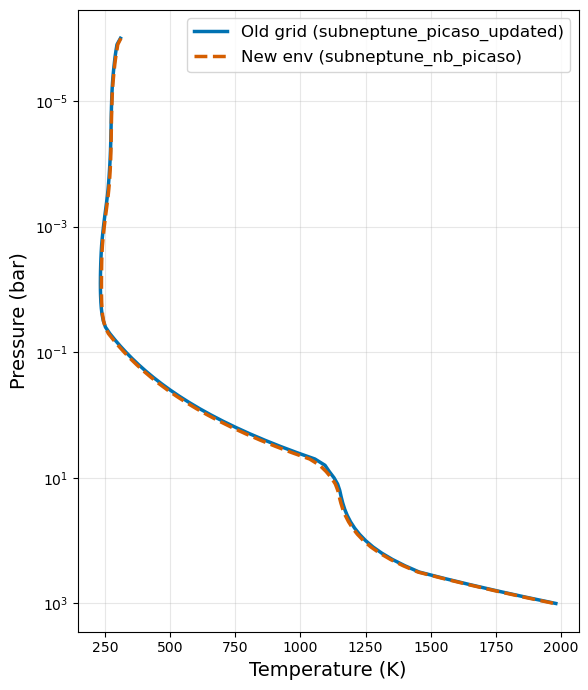

In [22]:
# Compare the PT profiles
fig, ax = plt.subplots(1, 1, figsize=(6, 7))
ax.semilogy(PT_list_picaso_old[1], PT_list_picaso_old[0], color='#0072B2', lw=2.5,
            label='Old grid (subneptune_picaso_updated)')
ax.semilogy(result_new['temperature'], result_new['pressure'], color='#D55E00', lw=2.5, ls='--',
            label='New env (subneptune_nb_picaso)')
ax.invert_yaxis()
ax.set_xlabel('Temperature (K)', fontsize=14)
ax.set_ylabel('Pressure (bar)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


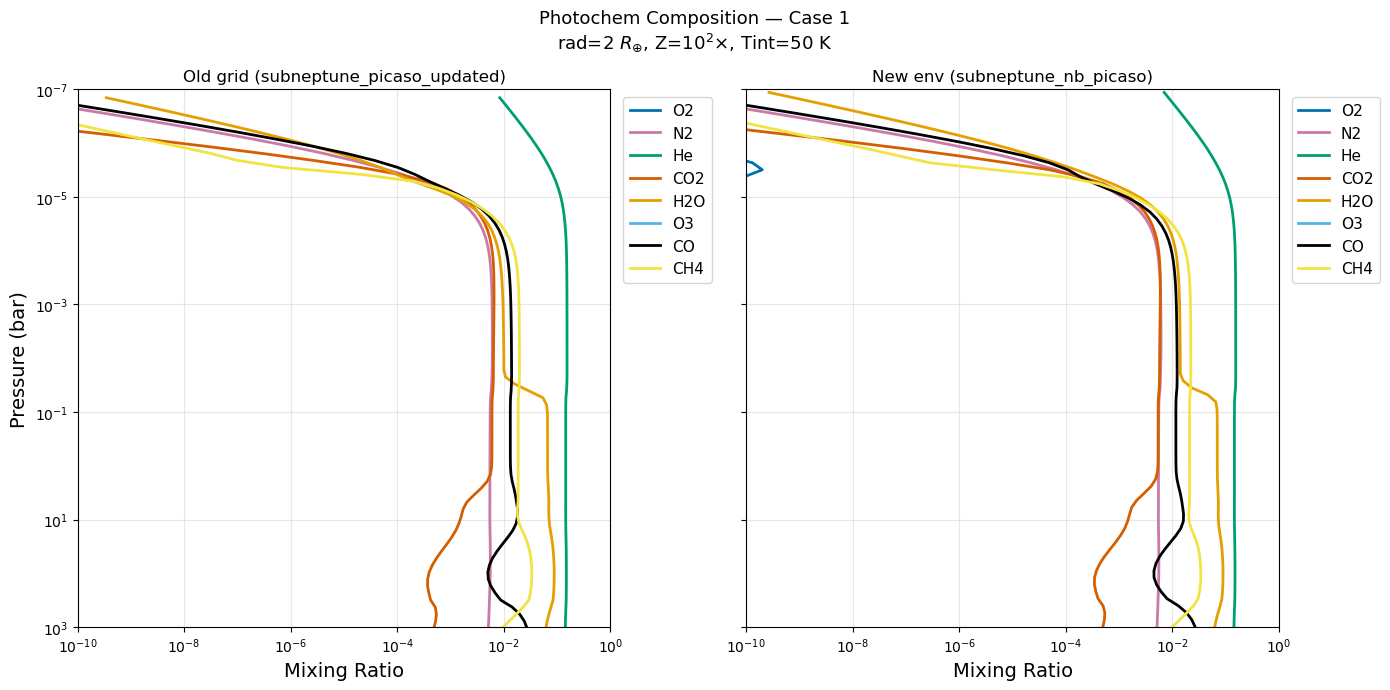

In [20]:
# Species to compare — adjust if some aren't in your Case 1 atmosphere
species_to_compare = ['O2', 'N2', 'He', 'CO2', 'H2O', 'O3', 'CO', 'CH4']
colors_sp = ['#0072B2', '#CC79A7', '#009E73', '#D55E00', '#E69F00', '#56B4E9', '#000000', '#F0E442']

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

for sp, color in zip(species_to_compare, colors_sp):
    # Old photochem (from original grid h5)
    if sp in sol_dict:
        p_old = np.array(sol_dict['pressure']) / 1e6  # dynes/cm² → bar
        axes[0].plot(sol_dict[sp], p_old, color=color, lw=2, label=sp)

    # New photochem (re-run with new PT profile)
    if sp in sol_new:
        p_new = np.array(sol_new['pressure']) / 1e6
        axes[1].plot(sol_new[sp], p_new, color=color, lw=2, label=sp)

for ax, title in zip(axes, ['Old grid (subneptune_picaso_updated)', 'New env (subneptune_nb_picaso)']):
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlim(1e-10, 1)
    ax.set_ylim(1000, 1e-7)
    ax.set_xlabel('Mixing Ratio', fontsize=14)
    ax.grid(alpha=0.3)
    ax.set_title(title, fontsize=12)
    ax.legend(ncol=1, fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left')

axes[0].set_ylabel('Pressure (bar)', fontsize=14)
fig.suptitle(
    f'Photochem Composition — Case 1\n'
    f'rad={rad_plan} $R_⊕$, Z=10$^{{{log10_metal}}}$×, Tint={tint} K',
    fontsize=13
)
plt.tight_layout()
plt.show()
